# 01 — ¿Es viable el estrato E3?

**Autor:** Jason Sepúlveda S.
**Depende de:** [`00-jss-corpus-y-auditoria.ipynb`](00-jss-corpus-y-auditoria.ipynb)

---

## El problema que resuelve este notebook

Al terminar la auditoría quedó un único número sin medir, y era el que más pesaba.

El aporte central del proyecto son las **relaciones temporales entre decisiones de reuniones distintas**.
El filtro de bloqueo selecciona **92 pares candidatos** de los 3.071 posibles, pero un
candidato no es una relación: es un par que vale la pena mirar. **¿Cuántos de esos 92 son
relaciones reales?**

De ese número depende el estrato E3 —las preguntas de evolución— que es donde se juega nuestra
hipótesis principal. La sección 5.5 de la propuesta pide un mínimo de 25 preguntas por estrato. Si resultaran
existir 20 relaciones, E3 no se sostiene y hay que reformularlo **antes** de invertir las
horas de anotación, no después.

Este notebook produce una **estimación provisional** de ese número, y de paso verifica seis
afirmaciones formuladas durante el piloto sin comprobarlas.

## ⚠️ Advertencia: estas etiquetas las puso una máquina

**Nada de este notebook es el conjunto de referencia, ni puede llegar a serlo.**

Si un modelo produce las etiquetas de OE1, entonces la condición C3 —definida en la sección
5.3 de la propuesta como *"la misma representación sin errores de extracción"*— tiene errores de extracción
por construcción, y la brecha C2 − C3, que es todo OE4, deja de medir nada.

Estas etiquetas existen por una razón distinta y mucho más modesta: **decidir si vale la pena
invertir las horas de anotación humana.** Es una estimación de planificación, no una
referencia.

Por eso:

- No se escribieron en ningún `*.candidates.csv`. Viven en `data/interim/`, fuera de la ruta
  del conjunto de referencia.
- **No deben mostrarse a un anotador antes de que anote**, porque anclarían su juicio.
- El anotador humano debe adjudicar estos mismos pares de forma independiente.

## Y solo sobre el conjunto de desarrollo

Adjudicar exige **leer el contenido** de las decisiones. El split del proyecto
([ADR 0005](../docs/decisions/0005-adr-development-evaluation-split.md)) separa los datos con
los que se toman decisiones de los datos con los que se reportan resultados, y leer el contenido de
evaluación lo contamina — incluso leérselo a uno mismo en un informe.

Así que la estimación se hace sobre las tres series de desarrollo: **ES2015, IS1004 y
TS3009**, que suman 11 candidatos. Es una muestra chica y el intervalo lo va a mostrar.

In [1]:
import pandas as pd

from afg.evaluation.metrics import wilson_interval
from afg.shared.paths import DATA_DIR

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 130)

ADJ = pd.read_csv(DATA_DIR / "interim" / "provisional-dev-adjudication.csv")
P8 = pd.read_csv(DATA_DIR / "interim" / "p8-verificacion-candidatos-a-ojo.csv")

print(f"Candidatos de desarrollo adjudicados: {len(ADJ)}")
print(f"Series: {', '.join(sorted(ADJ['series_id'].unique()))}")

Candidatos de desarrollo adjudicados: 11
Series: ES2015, IS1004, TS3009


---

# 1. La adjudicación

Cada par se contrastó **contra la transcripción**, no contra el resumen. Esa disciplina viene
del caso del botón turbo documentado en el notebook 00: el resumen abstractivo de AMI afirma
una eliminación que la transcripción contradice.

In [2]:
display(ADJ[["pair_id", "earlier_decision_id", "later_decision_id",
             "relation", "confidence"]])

,pair_id,earlier_decision_id,later_decision_id,relation,confidence
0,ES2015.p001,ES2015a.elana.s.11,ES2015b.elana.s.11,refina,alta
1,ES2015.p002,ES2015c.elana.s.19,ES2015d.elana.s.15,reafirma,alta
2,ES2015.p003,ES2015c.elana.s.20,ES2015d.elana.s.17,reafirma,alta
3,IS1004.p001,IS1004a.elana.s.14,IS1004b.elana.s.13,no_relacionada,baja
4,IS1004.p002,IS1004a.elana.s.14,IS1004b.elana.s.14,no_relacionada,alta
5,IS1004.p003,IS1004c.elana.s.29,IS1004d.elana.s.22,no_relacionada,alta
6,IS1004.p004,IS1004c.elana.s.29,IS1004d.elana.s.12,refina,alta
7,TS3009.p001,TS3009b.vkaraisk.s.14,TS3009c.vkaraisk.s.15,no_relacionada,media
8,TS3009.p002,TS3009b.vkaraisk.s.15,TS3009c.vkaraisk.s.14,no_relacionada,baja
9,TS3009.p003,TS3009b.vkaraisk.s.13,TS3009c.vkaraisk.s.17,no_relacionada,alta


In [3]:
resumen = (ADJ["relation"].value_counts().rename_axis("relacion")
           .to_frame("n"))
resumen["%"] = (resumen["n"] / len(ADJ) * 100).round(1)
display(resumen)

n = len(ADJ)
k = int((ADJ["relation"] != "no_relacionada").sum())
print(f"\nRelaciones reales (distintas de 'no_relacionada'): {k} de {n}")

,n,%
relacion,,
no_relacionada,6,54.5
refina,2,18.2
reafirma,2,18.2
reemplaza,1,9.1



Relaciones reales (distintas de 'no_relacionada'): 5 de 11


---

# 2. La tasa de positivos y su intervalo

Se usa el intervalo de **Wilson** y no la aproximación normal (Wald). Con n = 11, Wald se
comporta mal: puede producir límites fuera de `[0, 1]` y colapsa a ancho cero cuando el conteo
observado es 0 o n. Wilson se queda dentro del intervalo unitario y conserva un ancho
razonable en los extremos.

La implementación está en `afg.evaluation.metrics.wilson_interval`, con tests, siguiendo la
regla del proyecto de que ninguna cifra se calcula dentro de un notebook.

In [4]:
ci = wilson_interval(k, n)
print(f"Tasa de positivos = {ci.point_estimate:.1%}")
print(f"IC 95% (Wilson)   = [{ci.lower:.1%}, {ci.upper:.1%}]")

filas = []
for ambito, poblacion in [("Las 14 series", 92), ("Solo evaluacion", 81),
                          ("Solo desarrollo", 11)]:
    punto, bajo, alto = ci.scaled_to(poblacion)
    filas.append({"ambito": ambito, "candidatos": poblacion,
                  "relaciones esperadas": round(punto),
                  "IC 95% bajo": round(bajo), "IC 95% alto": round(alto)})
display(pd.DataFrame(filas))

Tasa de positivos = 45.5%
IC 95% (Wilson)   = [21.3%, 72.0%]


,ambito,candidatos,relaciones esperadas,IC 95% bajo,IC 95% alto
0,Las 14 series,92,42,20,66
1,Solo evaluacion,81,37,17,58
2,Solo desarrollo,11,5,2,8


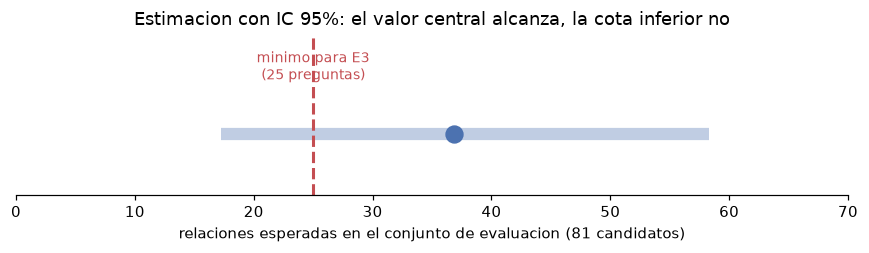

In [5]:
import matplotlib.pyplot as plt

punto, bajo, alto = ci.scaled_to(81)
fig, ax = plt.subplots(figsize=(8, 2.4), dpi=110)
ax.hlines(0, bajo, alto, color="#4C72B0", linewidth=8, alpha=0.35)
ax.plot([punto], [0], "o", color="#4C72B0", markersize=11)
ax.axvline(25, color="#C44E52", linestyle="--", linewidth=2)
ax.annotate("minimo para E3\n(25 preguntas)", xy=(25, 0), xytext=(25, 0.55),
            ha="center", color="#C44E52", fontsize=9)
ax.set_xlim(0, 70)
ax.set_ylim(-0.6, 1.0)
ax.set_yticks([])
ax.set_xlabel("relaciones esperadas en el conjunto de evaluacion (81 candidatos)")
ax.set_title("Estimacion con IC 95%: el valor central alcanza, la cota inferior no")
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Lectura

| | |
|---|---|
| Tasa de positivos | **45,5 %** (5 de 11) |
| IC 95 % | **[21,3 % – 72,0 %]** |
| Relaciones esperadas en evaluación | **~37**, IC **[17 – 58]** |

**El valor central da holgura para E3; la cota inferior del intervalo no alcanza.**

Con n = 11 lo honesto es decir que **E3 es plausible, no que sea viable**. La diferencia
importa: si se escribiera "el estrato E3 es viable" apoyado en once observaciones, se estaría
haciendo exactamente lo que la sección 5.0 de la propuesta prohíbe — afirmar sobre diferencias que caen
dentro del intervalo.

**Lo que estrecharía esto no es más razonamiento: es adjudicar una serie de evaluación a
mano.** Con ~8 candidatos más el intervalo se reduce sustancialmente, y esas etiquetas sí
serían parte del conjunto de referencia.

---

# 3. La primera relación verificada del proyecto

De los cinco positivos, uno merece detalle porque es exactamente el fenómeno que la tesis
quiere medir.

**TS3009c → TS3009d — `reemplaza`**

- **Antes (reunión c):** *"The case will be titanium with a plastic front with rounded
  buttons."*
- **Después (reunión d):** *"They also decided to replace titanium with similar-looking
  plastic for the same reason."*

El resumen dice "replace ... for the same reason", pero el resumen ya había inducido a error una vez. Se acudió a
la transcripción (`words/TS3009d.A.words.xml`):

> *"Well the titanium I don't want to lose actually."*
> … *"You want to dump the titanium? And make all plastic, then we're there."*
> … *"We have to dump our titanium, and we'll hate the managers for that."*

Una decisión de materiales revertida por presupuesto, con la resistencia del equipo
registrada. **Esto es una relación entre reuniones que ningún RAG documental puede
representar como relación**: los dos pasajes hablan del mismo tema, así que compiten por el
mismo espacio de contexto, y la recuperación por similitud puede devolver uno u otro sin
ninguna señal de cuál está vigente. Es el argumento de la sección 1.2 de la propuesta, instanciado.

---

# 4. Dos casos que la guía de anotación todavía no resuelve

Dos de los once quedaron con confianza **baja**, y por la misma razón de fondo:
**¿qué cuenta como "el mismo objeto de decisión"?**

In [6]:
display(ADJ[ADJ["confidence"] == "baja"][
    ["pair_id", "earlier_decision_id", "later_decision_id", "relation", "notes"]])

,pair_id,earlier_decision_id,later_decision_id,relation,notes
3,IS1004.p001,IS1004a.elana.s.14,IS1004b.elana.s.13,no_relacionada,el objetivo del proyecto lo inyecta el escenario; dudoso...
8,TS3009.p002,TS3009b.vkaraisk.s.15,TS3009c.vkaraisk.s.14,no_relacionada,mismo objeto (botones) pero propiedad distinta: cuales v...


- **`IS1004.p001`** — ¿es una decisión el objetivo del proyecto? Lo inyecta el escenario; el
  equipo no lo decide. La sección 5.2 de la propuesta exige que una decisión sea un *compromiso aceptado sobre
  una acción o propiedad del producto*, y no dice qué hacer con los requisitos dados.
- **`TS3009.p002`** — "qué botones lleva el control" y "de qué material son los botones"
  comparten el objeto *botones* pero son propiedades distintas. ¿`refina` o `no_relacionada`?

**Esto hay que zanjarlo en la guía antes de anotar.** Si no, dos anotadores van a diferir de
forma sistemática justo en estos casos, y el kappa lo va a reflejar sin explicar por qué —
que es precisamente el escenario de la sección 1.4 de la propuesta, donde dos equipos
competentes obtuvieron acuerdo peor que el azar sobre el mismo corpus.

---

# 5. P8 — verificando seis afirmaciones del piloto

Durante el piloto se listaron seis relaciones posibles entre reuniones, identificadas **a ojo, sin
trazar la transcripción**. Quedaron anotadas como hipótesis. Esta sección las verifica.

In [7]:
display(P8[["id", "afirmacion_piloto", "veredicto", "relacion_verificada", "motivo"]])

ok = int((P8["veredicto"] == "confirmado").sum())
print(f"\nConfirmadas: {ok} de {len(P8)}  ({ok/len(P8):.0%})")

,id,afirmacion_piloto,veredicto,relacion_verificada,motivo
0,P8-1,reafirma,confirmado,reafirma,la evidencia de d repite la decision de c sin cambiarla
1,P8-2,reafirma o refina,confirmado,reafirma,mismo material; el motivo agregado no cambia la decision
2,P8-3,refina,refutado,no_relacionada,la evidencia de 'dos colores' nunca menciona la marca; o...
3,P8-4,reafirma,confirmado,reafirma,'Thus far ... have been ruled out' es un repaso explicit...
4,P8-5,existe la decision anterior?,refutado,NaN,no existe decision previa de doble curvatura en IS1004; ...
5,P8-6,revierte,refutado,no_relacionada,el resumen afirma una eliminacion que la transcripcion c...



Confirmadas: 3 de 6  (50%)


## El 50 % de los juicios a ojo estaban equivocados

Las tres refutadas:

- **Color corporativo (ES2015 b→d).** Se afirmó `refina`. La evidencia de *"dos colores, uno para
  la carcasa y otro para los botones"* no menciona la marca en ningún momento. Son objetos
  distintos.
- **"Single, not double curve" (IS1004d).** Se supuso que revertía una decisión previa de doble
  curvatura. **Esa decisión no existe en IS1004.** La única del corpus está en ES2015d — otra
  serie completamente distinta.
- **Botón turbo (IS1004 c→d).** Ya documentado en el notebook 00: el resumen afirma una
  eliminación que la transcripción contradice.

## Tres consecuencias

**1. Es el argumento más fuerte a favor de la anotación humana verificada.** Un juicio rápido
sobre el par de frases —que es exactamente lo que hace un extractor automático— acertó la
mitad de las veces. **Ese es el orden de magnitud del error que OE4 se propone atribuir**, y
aparece aquí sin haber corrido todavía ningún modelo.

**2. La capa de decisiones abstractivas tiene huecos.** El caso de la curvatura lo muestra:
hay relaciones reales cuyo extremo anterior **nunca se registró como decisión**. La Tarea A
debe anotarlas en `notes` en vez de descartarlas en silencio, o el conjunto de referencia
heredará el hueco sin dejar rastro.

**3. Una afirmación anterior queda con apoyo parcial, no demostrada.** Se había planteado que
los flags `external`/`recap` de AMI subcuentan las relaciones reales. El caso **P8-4**
(IS1004 b→c, LCD y ASR descartados) es una relación real que **el filtro no seleccionó**: un
falso negativo confirmado. Pero viene de una sonda no aleatoria, así que **no reemplaza la
muestra de recall** de la Tarea C, que es la medición que corresponde.

---

# 6. Conclusión y qué sigue

## Lo que este notebook establece

- La tasa de positivos del filtro es **45,5 %**, IC 95 % **[21,3 % – 72,0 %]**, sobre n = 11.
- Proyectado a evaluación: **~37 relaciones**, IC **[17 – 58]**.
- **E3 es plausible, no demostrado.** El valor central alcanza para 25 preguntas; la cota
  inferior no.
- Existe al menos una relación entre reuniones verificada contra transcripción
  (TS3009c → TS3009d, `reemplaza`).
- El filtro tiene al menos un falso negativo confirmado.
- La guía de anotación tiene una ambigüedad pendiente sobre qué es "el mismo objeto de
  decisión".

## Lo que NO establece

- **Nada sobre el conjunto de evaluación.** Sus 81 candidatos no se miraron, a propósito.
- **Ninguna etiqueta de referencia.** Todo lo de aquí es provisional y de máquina.
- **La tasa real de positivos**, que solo la anotación humana puede fijar.

## Siguiente paso

Adjudicar **una serie de evaluación** a mano, siguiendo
[`docs/anotacion/manual-anotacion-oe1.md`](../docs/anotacion/manual-anotacion-oe1.md).
Estrecharía el intervalo mucho más que cualquier razonamiento adicional, y a diferencia de
todo lo de este notebook, **esas etiquetas sí formarían parte del conjunto de referencia**.

Antes de eso hay que cerrar la ambigüedad de la sección 4 en la guía de anotación.

---

*La anotación humana se registra en `02-jss-anotacion-oe1.ipynb`.*